<a href="https://colab.research.google.com/github/ITZYASHZ/northstar_analytics/blob/main/northstar_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn -q
print("Libraries ready!")

Libraries ready!


In [3]:
from google.colab import files
uploaded = files.upload()
# When the upload box appears, select ALL 9 CSV files at once from
# E:/Database/northstar_dataset

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving vehicles.csv to vehicles.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders      = pd.read_csv("orders.csv")
deliveries  = pd.read_csv("deliveries.csv")
customers   = pd.read_csv("customers.csv")
drivers     = pd.read_csv("drivers.csv")
vehicles    = pd.read_csv("vehicles.csv")
incidents   = pd.read_csv("incidents.csv")
complaints  = pd.read_csv("complaints.csv")
hubs        = pd.read_csv("hubs.csv")
app_events  = pd.read_csv("app_events.csv")

print("All files loaded!")
print(f"Orders: {len(orders)} rows")
print(f"Deliveries: {len(deliveries)} rows")
print(f"Complaints: {len(complaints)} rows")

All files loaded!
Orders: 1250 rows
Deliveries: 950 rows
Complaints: 320 rows


In [13]:
# NORTHSTAR - Python Data Processing
# Part 3: Pandas & NumPy Analysis

# Check missing values across all datasets
print("=== MISSING VALUES ===")
for name, df in [("orders", orders), ("deliveries", deliveries),
                  ("customers", customers), ("drivers", drivers),
                  ("vehicles", vehicles), ("incidents", incidents),
                  ("complaints", complaints)]:
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} missing values")

# Fix missing values (updated syntax)
deliveries["customer_rating_post_delivery"] = deliveries["customer_rating_post_delivery"].fillna(
    deliveries["customer_rating_post_delivery"].median())

customers["loyalty_score"] = customers["loyalty_score"].fillna(
    customers["loyalty_score"].median())

drivers["driver_rating"] = drivers["driver_rating"].fillna(
    drivers["driver_rating"].median())

complaints["compensation_amount"] = complaints["compensation_amount"].fillna(0)

print("\n=== AFTER CLEANING ===")
print("Missing values fixed!")

=== MISSING VALUES ===
orders: 25 missing values
deliveries: 19 missing values
customers: 13 missing values
drivers: 7 missing values
vehicles: 4 missing values
incidents: 17 missing values
complaints: 0 missing values

=== AFTER CLEANING ===
Missing values fixed!


=== DELIVERY FAILURE RATE BY ZONE ===
   pickup_zone  total  failed  failure_rate
9    RiverSide     66      14         21.21
3      Central     55      11         20.00
2      CENTRAL     55      11         20.00
8        North     37       7         18.92
4          Ctr     64      11         17.19
15       north     52       8         15.38
7        NORTH     46       7         15.22
5         EAST     78      11         14.10
14        West     51       7         13.73
12       South     83      10         12.05
1      Airport     67       8         11.94
13        WEST     63       7         11.11
6         East     78       8         10.26
0      AIRPORT     46       4          8.70
10   Riverside     53       4          7.55
11       SOUTH     56       4          7.14


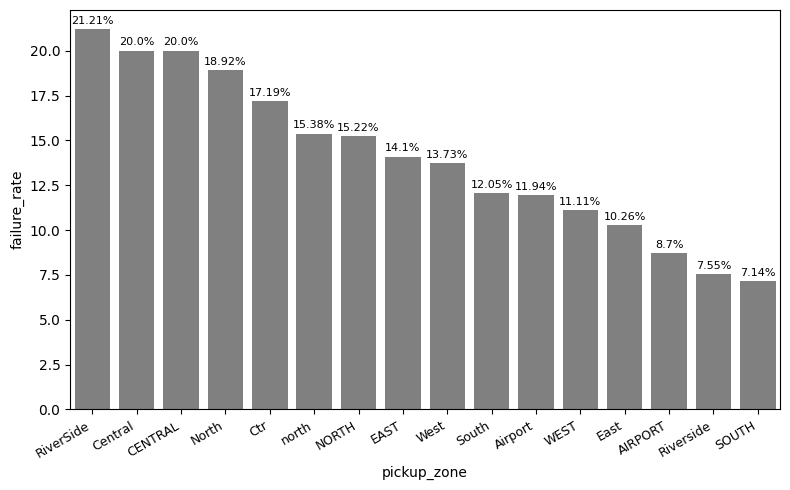

Chart saved!


In [6]:
# ANALYSIS 1: Delivery Failure Rate by Zone


merged = deliveries.merge(orders, on="order_id")

zone_failure = merged.groupby("pickup_zone").agg(
    total=("delivery_id", "count"),
    failed=("delivery_status", lambda x: (x == "Failed").sum())
).reset_index()

zone_failure["failure_rate"] = round(
    zone_failure["failed"] / zone_failure["total"] * 100, 2)

zone_failure = zone_failure.sort_values("failure_rate", ascending=False)

print("=== DELIVERY FAILURE RATE BY ZONE ===")
print(zone_failure)

# Chart
plt.figure(figsize=(8, 5))

# Grey bars
sns.barplot(
    data=zone_failure,
    x="pickup_zone",
    y="failure_rate",
    color="grey"
)

# Rotate + smaller font
plt.xticks(rotation=30, ha="right", fontsize=9)

# Value labels
for i, row in zone_failure.reset_index().iterrows():
    plt.text(
        i,
        row["failure_rate"] + 0.3,
        f'{row["failure_rate"]}%',
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.savefig("chart1_zone_failure.png", dpi=150)
plt.show()

print("Chart saved!")

=== PERFORMANCE BY SERVICE TYPE ===
  service_type  total_orders  failed  avg_cost  avg_rating  failure_rate
0     Business           126      25     13.14        3.85         19.84
1      Medical           108      16     12.77        3.84         14.81
2       Parcel           230      25     13.08        3.90         10.87
3    Passenger           262      38     12.40        3.85         14.50
4       Retail           224      28     12.97        3.88         12.50


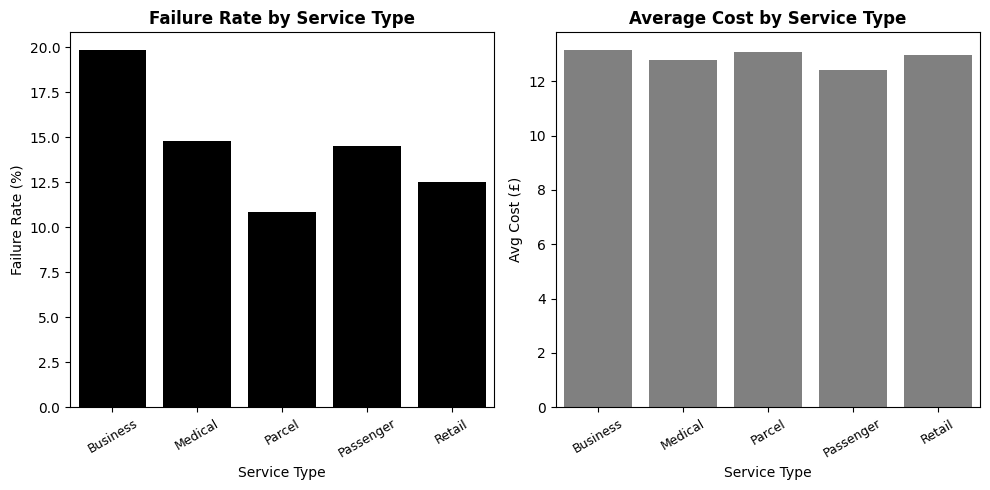

Chart saved!


In [7]:

# ANALYSIS 2: Performance by Service Type

service_perf = merged.groupby("service_type").agg(
    total_orders=("order_id", "count"),
    failed=("delivery_status", lambda x: (x == "Failed").sum()),
    avg_cost=("fuel_or_charge_cost", "mean"),
    avg_rating=("customer_rating_post_delivery", "mean")
).reset_index()

service_perf["failure_rate"] = round(
    service_perf["failed"] / service_perf["total_orders"] * 100, 2)

service_perf["avg_cost"] = round(service_perf["avg_cost"], 2)
service_perf["avg_rating"] = round(service_perf["avg_rating"], 2)

print("=== PERFORMANCE BY SERVICE TYPE ===")
print(service_perf)

# Chart
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# LEFT GRAPH
sns.barplot(
    data=service_perf,
    x="service_type",
    y="failure_rate",
    color="black",
    ax=axes[0]
)

axes[0].set_title("Failure Rate by Service Type", fontweight="bold")
axes[0].set_xlabel("Service Type")
axes[0].set_ylabel("Failure Rate (%)")
axes[0].tick_params(axis="x", rotation=30, labelsize=9)

# RIGHT GRAPH
sns.barplot(
    data=service_perf,
    x="service_type",
    y="avg_cost",
    color="grey",
    ax=axes[1]
)

axes[1].set_title("Average Cost by Service Type", fontweight="bold")
axes[1].set_xlabel("Service Type")
axes[1].set_ylabel("Avg Cost (£)")
axes[1].tick_params(axis="x", rotation=30, labelsize=9)

plt.tight_layout()
plt.savefig("chart2_service_type.png", dpi=150)
plt.show()

print("Chart saved!")

=== TOP 10 DRIVERS BY OVERRIDES ===
    driver_id  base_zone  total_jobs  total_overrides  success_rate
126      D127    CENTRAL           6               17         100.0
86       D087      north          12               16          83.3
129      D130       WEST           8               16          87.5
107      D108      South          11               15          72.7
130      D131      SOUTH           9               15          66.7
68       D069      NORTH           7               14          85.7
104      D105  RiverSide           7               14          85.7
16       D017       EAST          10               13          80.0
27       D028      North           7               13          85.7
7        D008      SOUTH           8               12         100.0


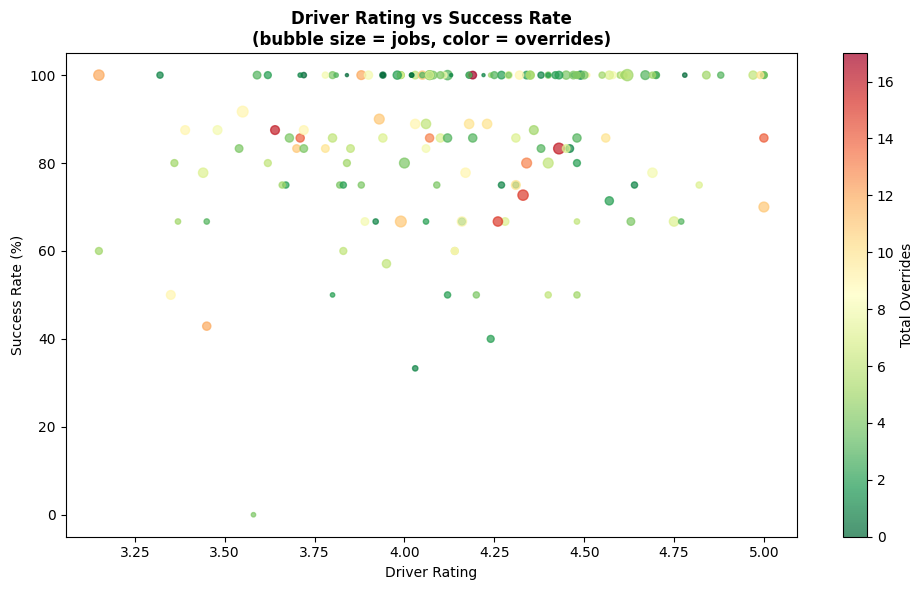

Chart saved!


In [8]:
# ANALYSIS 3: Driver Performance Analysis

driver_perf = deliveries.merge(drivers, on="driver_id")

driver_summary = driver_perf.groupby(
    ["driver_id", "driver_rating", "base_zone", "employment_type"]).agg(
    total_jobs=("delivery_id", "count"),
    total_overrides=("manual_route_override_count", "sum"),
    avg_cust_rating=("customer_rating_post_delivery", "mean"),
    failures=("delivery_status", lambda x: (x == "Failed").sum())
).reset_index()

driver_summary["success_rate"] = round(
    (1 - driver_summary["failures"] / driver_summary["total_jobs"]) * 100, 1)
driver_summary["avg_cust_rating"] = round(driver_summary["avg_cust_rating"], 2)

print("=== TOP 10 DRIVERS BY OVERRIDES ===")
print(driver_summary.nlargest(10, "total_overrides")[
    ["driver_id","base_zone","total_jobs","total_overrides","success_rate"]])

# Chart
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    driver_summary["driver_rating"],
    driver_summary["success_rate"],
    c=driver_summary["total_overrides"],
    cmap="RdYlGn_r",
    s=driver_summary["total_jobs"] * 5,
    alpha=0.7
)
plt.colorbar(scatter, label="Total Overrides")
plt.title("Driver Rating vs Success Rate\n(bubble size = jobs, color = overrides)",
          fontweight="bold")
plt.xlabel("Driver Rating")
plt.ylabel("Success Rate (%)")
plt.tight_layout()
plt.savefig("chart3_driver_performance.png", dpi=150)
plt.show()
print("Chart saved!")

=== AT-RISK VEHICLES ===
Total at-risk vehicles: 116
    vehicle_id vehicle_type  battery_health_pct maintenance_status  \
44        V047           EV                93.7          Scheduled   
103       V108       Diesel                54.6           InRepair   
43        V046           EV                95.8             Active   
27        V030     CargoVan                78.0             Active   
93        V097           EV                92.1             Active   
7         V009     CargoVan                68.8             Active   
32        V035     CargoVan                83.6             Active   
3         V005     CargoVan                58.6             Active   
84        V088       Diesel                80.3           InRepair   
72        V076       Diesel                65.8           InRepair   

    assigned_zone  incident_count  total_deliveries  
44            Ctr               9                18  
103       AIRPORT               7                11  
43          no

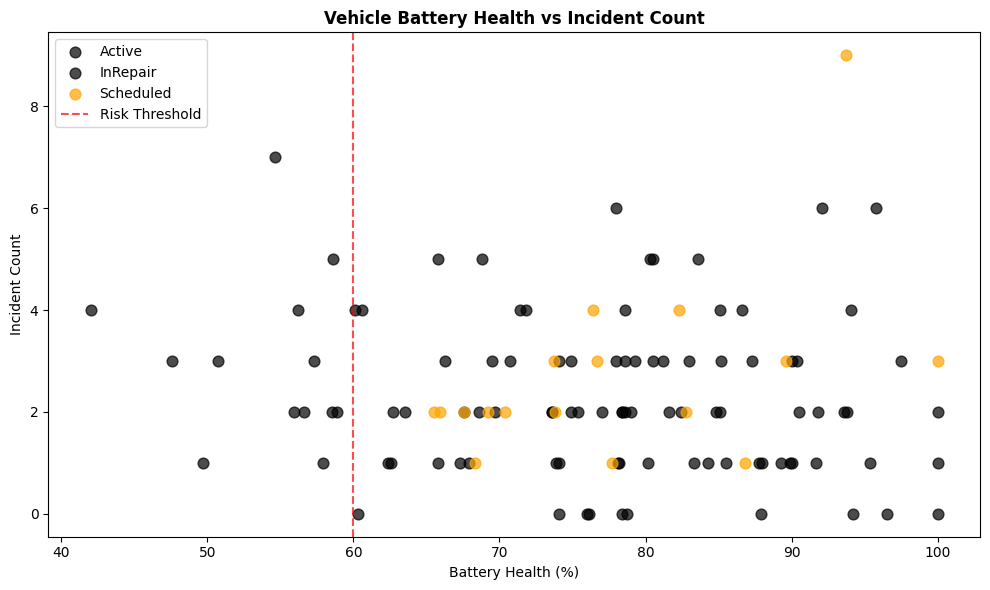

Chart saved!


In [12]:
# ANALYSIS 4: Vehicle Risk Analysis

vehicle_incidents = deliveries.merge(
    incidents, on="delivery_id", how="left").merge(
    vehicles, on="vehicle_id")

vehicle_risk = vehicle_incidents.groupby(
    ["vehicle_id", "vehicle_type", "battery_health_pct",
     "maintenance_status", "assigned_zone"]).agg(
    incident_count=("incident_id", "count"),
    total_deliveries=("delivery_id", "count")
).reset_index()

at_risk = vehicle_risk[
    (vehicle_risk["battery_health_pct"] < 65) |
    (vehicle_risk["maintenance_status"] != "OK")
].sort_values("incident_count", ascending=False)

print("=== AT-RISK VEHICLES ===")
print(f"Total at-risk vehicles: {len(at_risk)}")
print(at_risk.head(10))

# Chart
plt.figure(figsize=(10, 6))
colors = {"OK": "green", "Scheduled": "orange", "Overdue": "red"}
for status, group in vehicle_risk.groupby("maintenance_status"):
    plt.scatter(group["battery_health_pct"], group["incident_count"],
                label=status, color=colors.get(status, "black"),
                alpha=0.7, s=60)
plt.axvline(x=60, color="red", linestyle="--", alpha=0.7, label="Risk Threshold")
plt.title("Vehicle Battery Health vs Incident Count", fontweight="bold")
plt.xlabel("Battery Health (%)")
plt.ylabel("Incident Count")
plt.legend()
plt.tight_layout()
plt.savefig("chart4_vehicle_risk.png", dpi=150)
plt.show()
print("Chart saved!")

=== COMPLAINTS BY TYPE AND SEVERITY ===
       complaint_type severity  count  avg_compensation  avg_resolution_days
0            AppIssue     High     13             31.43                 13.9
1            AppIssue      Low     15             12.37                  6.1
2            AppIssue   Medium     25             15.46                  7.4
3             Billing     High      4             52.32                 12.0
4             Billing      Low      3              6.86                  8.0
5             Billing   Medium      9             16.90                  5.8
6              Damage     High      7             37.26                 15.4
7              Damage      Low      6             10.84                  6.8
8              Damage   Medium      2             16.94                 10.5
9               Delay     High     18             28.42                 12.4
10              Delay      Low     27              8.16                  6.5
11              Delay   Medium     5

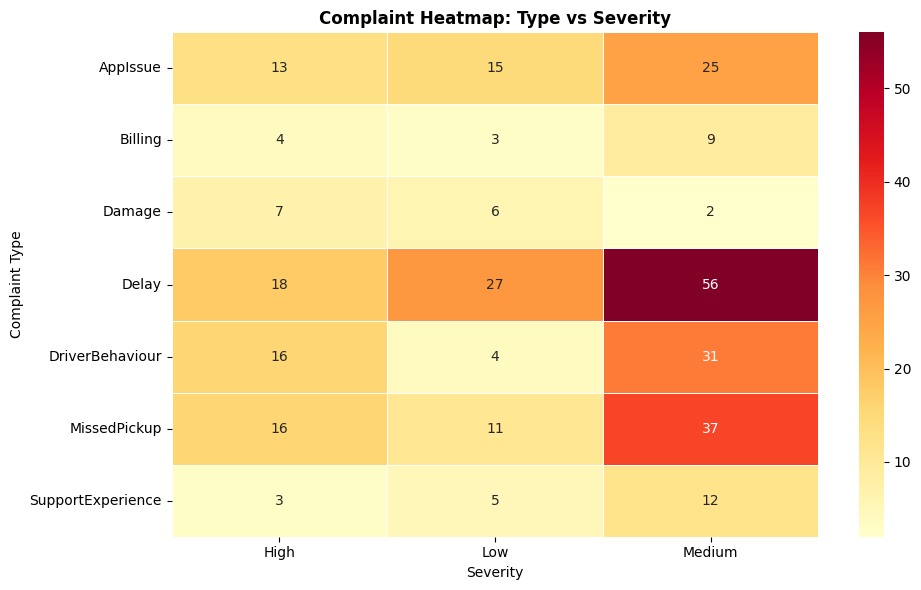

Chart saved!


In [10]:
# ANALYSIS 5: Complaints Deep Dive

complaints_full = complaints.merge(customers, on="customer_id")

comp_summary = complaints_full.groupby(
    ["complaint_type", "severity"]).agg(
    count=("complaint_id", "count"),
    avg_compensation=("compensation_amount", "mean"),
    avg_resolution_days=("resolution_days", "mean")
).reset_index()

comp_summary["avg_compensation"] = round(comp_summary["avg_compensation"], 2)
comp_summary["avg_resolution_days"] = round(comp_summary["avg_resolution_days"], 1)

print("=== COMPLAINTS BY TYPE AND SEVERITY ===")
print(comp_summary)

# Heatmap
pivot = complaints_full.pivot_table(
    index="complaint_type",
    columns="severity",
    values="complaint_id",
    aggfunc="count",
    fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)
plt.title("Complaint Heatmap: Type vs Severity", fontweight="bold")
plt.xlabel("Severity")
plt.ylabel("Complaint Type")
plt.tight_layout()
plt.savefig("chart5_complaints_heatmap.png", dpi=150)
plt.show()
print("Chart saved!")

=== HUB EFFICIENCY SUMMARY ===
         hub_name       zone   hub_type  total_deliveries  failures  avg_cost  \
3   Midtown Relay    Central   Charging               128        26     11.71   
1    Central Core    Central    Control               115        23     13.69   
0     Airport Hub    Airport   Dispatch               104        15     13.32   
7       West Gate       West   Dispatch               127        16     13.17   
4  North Exchange      North   Dispatch               136        17     12.76   
5   Riverside Hub  Riverside  Warehouse               115        14     12.92   
6      South Link      South   Dispatch               106        10     12.57   
2       East Dock       East  Warehouse               119        11     12.74   

   avg_distance  failure_rate  
3     12.815469         20.31  
1     14.321652         20.00  
0     14.412212         14.42  
7     13.384567         12.60  
4     13.643309         12.50  
5     14.286957         12.17  
6     14.169151

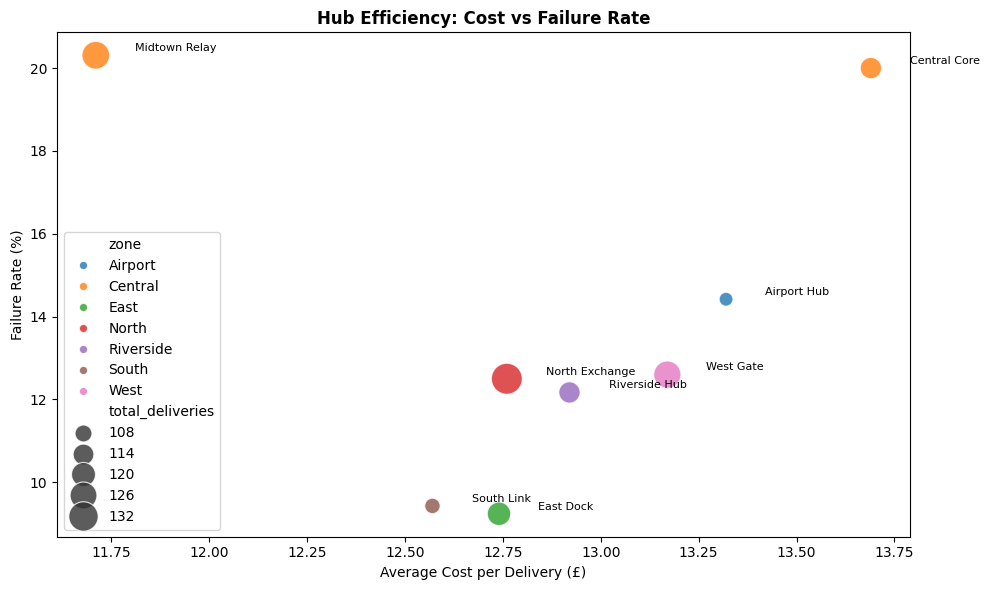

Chart saved!


In [11]:
# ANALYSIS 6: Hub Efficiency Summary


hub_perf = deliveries.merge(hubs, on="hub_id").merge(orders, on="order_id")

hub_summary = hub_perf.groupby(["hub_name", "zone", "hub_type"]).agg(
    total_deliveries=("delivery_id", "count"),
    failures=("delivery_status", lambda x: (x == "Failed").sum()),
    avg_cost=("fuel_or_charge_cost", "mean"),
    avg_distance=("route_distance_km", "mean")
).reset_index()

hub_summary["failure_rate"] = round(
    hub_summary["failures"] / hub_summary["total_deliveries"] * 100, 2)
hub_summary["avg_cost"] = round(hub_summary["avg_cost"], 2)

print("=== HUB EFFICIENCY SUMMARY ===")
print(hub_summary.sort_values("failure_rate", ascending=False))

# Chart
plt.figure(figsize=(10, 6))
sns.scatterplot(data=hub_summary, x="avg_cost", y="failure_rate",
                hue="zone", size="total_deliveries",
                sizes=(100, 500), alpha=0.8)
for _, row in hub_summary.iterrows():
    plt.text(row["avg_cost"]+0.1, row["failure_rate"]+0.1,
             row["hub_name"], fontsize=8)
plt.title("Hub Efficiency: Cost vs Failure Rate", fontweight="bold")
plt.xlabel("Average Cost per Delivery (£)")
plt.ylabel("Failure Rate (%)")
plt.tight_layout()
plt.savefig("chart6_hub_efficiency.png", dpi=150)
plt.show()
print("Chart saved!")